# Chapter 01: Introduction: A Tour of Multiple View Geometry

Source orientation: printed pages 1-22; PDF pages 19-40.

This notebook is an original, standalone computational tour of the opening chapter. The source span was used to identify the chapter's sequence of ideas: projective space, camera projection, two-view and three-view relations, transfer, Euclidean upgrade, auto-calibration, dense reconstruction, and video augmentation. No textbook prose, figures, screenshots, page crops, or layouts are reproduced here.


## Chapter Goal

The chapter's main claim is that multiple-view geometry is not a bag of unrelated matrices. It is one projective language for answering three recurring questions:

1. What geometric information survives image formation?
2. What ambiguity remains after matching features across views?
3. Which extra assumptions upgrade a projective answer to an affine or Euclidean one?

The notebook turns those questions into executable objects. Homogeneous coordinates model finite points and points at infinity. Camera matrices model central projection. Homographies model plane-induced or same-center image transfer. The fundamental matrix models the two-view incidence constraint. A projective 4 by 4 transform models the unavoidable ambiguity of uncalibrated reconstruction. The image of the absolute conic appears as the calibration object that returns metric angle information.


## Computational Translation Guide

- **Projective point:** a nonzero homogeneous vector represents a scale class. In code, equality means agreement after normalization, not identical arrays.
- **Line and incidence:** a 2D line is a homogeneous 3-vector `l`; a point `x` lies on it when `l @ x = 0`.
- **Line at infinity:** choosing a special line turns projective geometry into affine geometry. Its image under a homography is the horizon or vanishing line.
- **Camera matrix:** a rank-3 matrix `P` maps a 3D homogeneous point `X` to an image point `x ~ P X`.
- **Homography:** when the camera center is fixed, or when all scene points are coplanar, image coordinates are related by a 3 by 3 projective transformation.
- **Fundamental matrix:** for two views of the same 3D point, `x2.T @ F @ x1 = 0`; the matrix has rank 2 and defines epipolar lines.
- **Projective ambiguity:** replacing every point by `H X` and every camera by `P H^{-1}` leaves every image measurement unchanged.
- **Metric upgrade:** calibration, encoded by the image of the absolute conic `omega = K^{-T} K^{-1}`, lets image measurements recover Euclidean ray angles.


## Library Routing

| Chapter concept | Representation in this notebook | Library route | Why this route fits | Validation |
| --- | --- | --- | --- | --- |
| Line at infinity, vanishing points, horizon | Static projective-plane construction | `numpy`, `matplotlib` | A labeled 2D construction makes incidence and line preservation inspectable without hiding the homogeneous coordinates. | Vanishing points lie on the transformed line at infinity and on the transformed parallel-line families. |
| Central projection and camera centers | Rotatable 3D camera/ray scene | `plotly`, `numpy` | The camera-center idea is spatial; an HTML 3D view lets the learner inspect rays, centers, image planes, and point cloud depth. | Camera matrices have rank 3; same-center and planar homography residuals are near zero. |
| Projective image warp | Synthetic raster grid and perspective warp | `opencv-contrib-python` (`cv2`), `matplotlib` | The chapter begins with pictures of squares and circles losing Euclidean shape; a synthetic grid avoids copyrighted images while using a vision-native transform. | OpenCV and homogeneous-coordinate point transforms agree. |
| Epipolar geometry, triangulation, transfer | Two image planes with epipolar lines and third-view transfer | `numpy`, course camera/epipolar helpers, `matplotlib` | The two-view constraint is a visible incidence relation in the image plane. | `rank(F)=2`, Sampson residuals near zero, triangulated points reproject to the third camera. |
| Projective ambiguity and Euclidean upgrade | Paired 3D point clouds plus distance-ratio diagnostic | `numpy`, `matplotlib` | The ambiguity is best seen by comparing unchanged image projections with visibly distorted 3D Euclidean distances. | Reprojection residual stays near zero while pairwise distance ratios are not constant. |
| Chapter route and proof scaffolding | Directed dependency graph | `networkx`, `matplotlib` | The introduction is a dependency tour; a graph shows which assumptions feed each later object. | The route graph is acyclic and connects projection to Euclidean applications. |


## Chapter-Specific Visual Storyboard

| Order | Artifact | Concept | Learner inspection target | Check |
| --- | --- | --- | --- | --- |
| 1 | `figures/vanishing-line-projective-strata.png` | Projective geometry preserves straight lines but not parallelism. | Follow two families of originally parallel lines to their vanishing points and the shared horizon. | Incidence with vanishing points and horizon. |
| 2 | `interactive/pinhole-rays-camera-centers.html` | A camera image is a coordinate chart on rays through a center. | Rotate the scene and compare camera centers, image planes, rays, and the shared point cloud. | Rank of each camera matrix and exact same-center/planar homographies. |
| 3 | `figures/projective-image-warp-lines-stay-lines.png` | Image warps can destroy shape while preserving line structure. | Compare the synthetic grid before and after a perspective warp. | OpenCV and homogeneous-coordinate point mapping agree. |
| 4 | `figures/two-view-epipolar-transfer.png` | Correspondences satisfy a two-view incidence constraint and can transfer to a third view through triangulation. | In the second image, each measured point sits on the epipolar line generated by the first view. | Rank-2 fundamental matrix, low Sampson error, low third-view transfer error. |
| 5 | `figures/projective-ambiguity-euclidean-upgrade.png` | Projective reconstruction can be image-perfect and metrically wrong. | Compare the point cloud before and after a 3D projective transform; inspect the spread of distance ratios. | Reprojection is preserved; Euclidean distances are not preserved by a single scale. |
| 6 | `figures/chapter-tour-route-graph.png` | The chapter is a chain from projective representation to calibrated applications. | Trace how calibration and extra assumptions enter after projective reconstruction. | Directed graph is acyclic and reaches the application nodes. |
| 7 | `figures/epipolar-noise-sensitivity.png` and `tables/two-view-noise-sensitivity.csv` | Linear initialization is useful but measurement noise changes residuals and triangulation quality. | Compare noise level to Sampson residual and triangulation error. | Table row count, positive error growth, and rank-2 estimates. |


In [1]:
from pathlib import Path
import sys

BOOK_ROOT = Path.cwd()
for candidate in [BOOK_ROOT, *BOOK_ROOT.parents]:
    if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
        BOOK_ROOT = candidate
        break
else:
    raise RuntimeError("Could not find the Multiple View Geometry book root")

if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

TOPIC = "chapter-01"
ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / TOPIC
FIG_DIR = ARTIFACT_ROOT / "figures"
HTML_DIR = ARTIFACT_ROOT / "interactive"
CHECK_DIR = ARTIFACT_ROOT / "checks"
TABLE_DIR = ARTIFACT_ROOT / "tables"
for directory in [FIG_DIR, HTML_DIR, CHECK_DIR, TABLE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)


In [2]:
from itertools import combinations

import cv2
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import plotly.graph_objects as go

from utils.artifacts import assert_artifacts, display_artifact, save_csv, save_json, save_matplotlib, save_plotly_html
from utils.cameras import camera_matrix, cube_points, look_at_rotation, make_calibration, project_points
from utils.epipolar import eight_point, fundamental_from_cameras, linear_triangulate, sampson_errors
from utils.projective import apply_homography, dehomogenize, dlt_homography, homogenize, incidence, line_through

np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(101)
artifact_paths = []
check_values = {}


def rotation_x(theta):
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[1.0, 0.0, 0.0], [0.0, c, -s], [0.0, s, c]])


def rotation_y(theta):
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c, 0.0, s], [0.0, 1.0, 0.0], [-s, 0.0, c]])


def make_tour_points():
    cube = cube_points(scale=0.55)
    plane = np.array([[x, y, 3.05] for x in np.linspace(-0.9, 0.9, 4) for y in np.linspace(-0.55, 0.55, 3)])
    ridge = np.array([[-0.75, -0.2, 2.55], [-0.25, 0.7, 3.85], [0.35, -0.65, 3.55], [0.85, 0.25, 2.75]])
    return np.vstack([cube, plane, ridge])


def make_tour_cameras():
    K = make_calibration(880.0, 860.0, 320.0, 240.0)
    centers = [np.array([-1.8, 0.45, -4.25]), np.array([1.65, 0.55, -4.05]), np.array([0.0, 1.45, -4.45])]
    target = np.array([0.0, 0.0, 3.05])
    rotations = [look_at_rotation(center, target=target) for center in centers]
    cameras = [camera_matrix(K, R, C) for R, C in zip(rotations, centers)]
    return K, rotations, centers, cameras


def normalize_image_points(points):
    pts = np.asarray(points, dtype=float)
    margin = 35.0
    return (pts[:, 0].min() - margin, pts[:, 0].max() + margin), (pts[:, 1].min() - margin, pts[:, 1].max() + margin)


def line_segment_in_box(line, xlim, ylim):
    a, b, c = np.asarray(line, dtype=float)
    candidates = []
    for x in xlim:
        if abs(b) > 1e-12:
            y = -(a * x + c) / b
            if ylim[0] - 1e-9 <= y <= ylim[1] + 1e-9:
                candidates.append((x, y))
    for y in ylim:
        if abs(a) > 1e-12:
            x = -(b * y + c) / a
            if xlim[0] - 1e-9 <= x <= xlim[1] + 1e-9:
                candidates.append((x, y))
    if len(candidates) < 2:
        return None
    return np.array(candidates[:2])


def normalized_incidence(line, point):
    l = np.asarray(line, dtype=float)
    p = np.asarray(point, dtype=float)
    p = p / p[-1] if abs(p[-1]) > 1e-12 else p / np.linalg.norm(p)
    denom = max(np.linalg.norm(l[:2]), 1e-12)
    return float(abs(l @ p) / denom)


def pairwise_distances(points):
    pts = np.asarray(points, dtype=float)
    return np.array([np.linalg.norm(pts[i] - pts[j]) for i, j in combinations(range(len(pts)), 2)])


points3d = make_tour_points()
K, rotations, centers, cameras = make_tour_cameras()
P1, P2, P3 = cameras
x1 = project_points(P1, points3d)
x2 = project_points(P2, points3d)
x3 = project_points(P3, points3d)


## 1. Projective Space: Where Parallel Lines Go

The chapter starts with a simple but disruptive observation: a picture can turn a square into a quadrilateral and a circle into an ellipse, yet straight lines remain straight. The correct invariant is not Euclidean shape; it is projective incidence.

The construction below starts with two families of parallel lines on a plane. A projective transformation sends their ideal points to finite vanishing points. The line at infinity moves to a visible horizon line, and every transformed line in a family passes through the appropriate vanishing point.


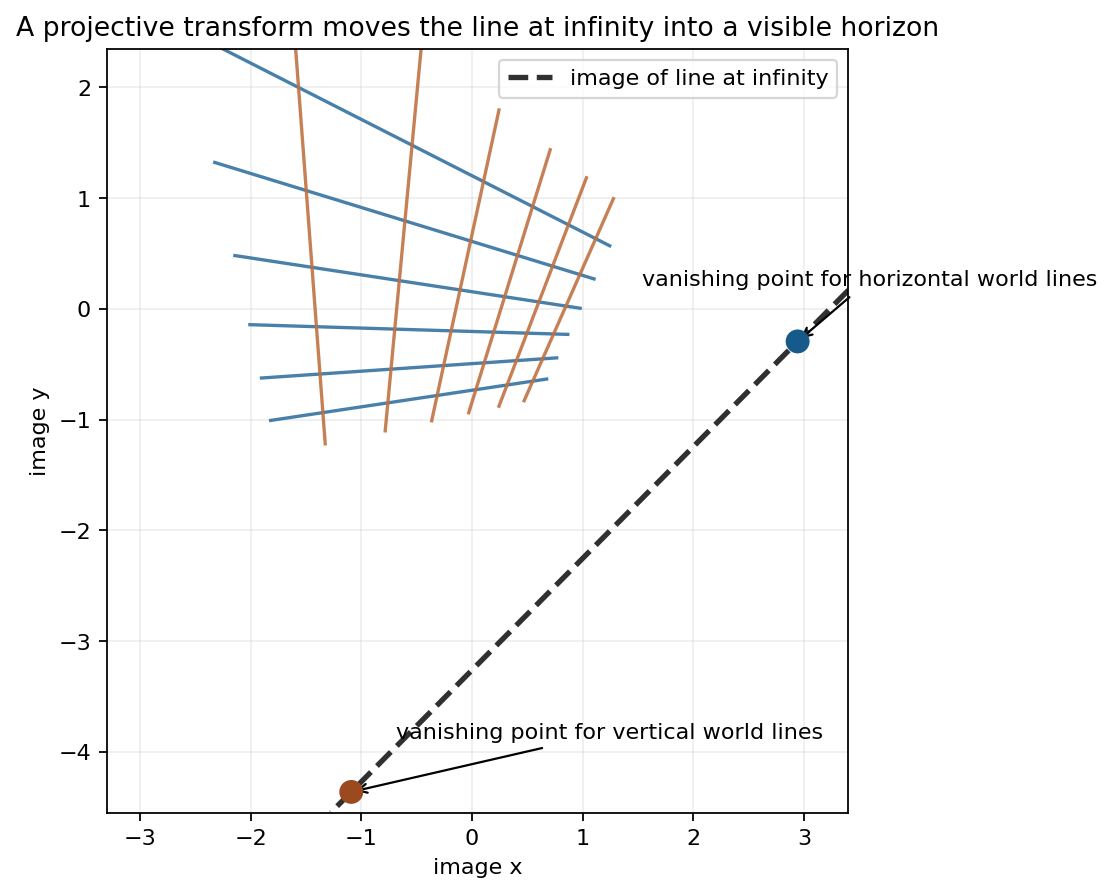

(4.0205214473426037e-16, 0.0)

In [3]:
H_plane = np.array([[1.0, 0.24, 0.06], [-0.10, 0.96, -0.04], [0.34, -0.22, 1.0]])
line_at_infinity = np.array([0.0, 0.0, 1.0])
horizon = np.linalg.inv(H_plane).T @ line_at_infinity
vx = H_plane @ np.array([1.0, 0.0, 0.0])
vy = H_plane @ np.array([0.0, 1.0, 0.0])
vx = vx / vx[-1]
vy = vy / vy[-1]

fig, ax = plt.subplots(figsize=(8.4, 6.2))
xs = np.linspace(-1.25, 1.25, 80)
y_values = np.linspace(-0.9, 0.9, 6)
x_values = np.linspace(-1.0, 1.0, 6)
family_residuals = []

for y in y_values:
    src = np.column_stack([xs, np.full_like(xs, y)])
    mapped = apply_homography(H_plane, src)
    ax.plot(mapped[:, 0], mapped[:, 1], color="#2f6f9f", lw=1.5, alpha=0.88)
    l_img = line_through(homogenize(mapped[[0]])[0], homogenize(mapped[[-1]])[0])
    family_residuals.append(normalized_incidence(l_img, vx))

for x in x_values:
    src = np.column_stack([np.full_like(xs, x), xs])
    mapped = apply_homography(H_plane, src)
    ax.plot(mapped[:, 0], mapped[:, 1], color="#bf6f3f", lw=1.5, alpha=0.88)
    l_img = line_through(homogenize(mapped[[0]])[0], homogenize(mapped[[-1]])[0])
    family_residuals.append(normalized_incidence(l_img, vy))

xlim = (-3.3, 3.4)
ylim = (-4.55, 2.35)
segment = line_segment_in_box(horizon, xlim, ylim)
if segment is not None:
    ax.plot(segment[:, 0], segment[:, 1], color="#303030", lw=2.4, ls="--", label="image of line at infinity")
ax.scatter([vx[0], vy[0]], [vx[1], vy[1]], s=95, c=["#155a8a", "#9b4a20"], zorder=5)
ax.annotate("vanishing point for horizontal world lines", vx[:2], xytext=(-70, 25), textcoords="offset points", arrowprops={"arrowstyle": "->", "lw": 1.0})
ax.annotate("vanishing point for vertical world lines", vy[:2], xytext=(20, 24), textcoords="offset points", arrowprops={"arrowstyle": "->", "lw": 1.0})
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_aspect("equal", adjustable="box")
ax.set_title("A projective transform moves the line at infinity into a visible horizon")
ax.set_xlabel("image x")
ax.set_ylabel("image y")
ax.grid(True, alpha=0.2)
ax.legend(loc="upper right")

vanishing_path = save_matplotlib(fig, TOPIC, "figures", "vanishing-line-projective-strata.png")
plt.close(fig)
artifact_paths.append(vanishing_path)
display_artifact(vanishing_path, width=820)

horizon_residual = max(normalized_incidence(horizon, vx), normalized_incidence(horizon, vy))
check_values.update({
    "vanishing_family_max_incidence": float(max(family_residuals)),
    "vanishing_points_on_horizon_residual": float(horizon_residual),
})
check_values["vanishing_family_max_incidence"], check_values["vanishing_points_on_horizon_residual"]


## 2. Cameras As Coordinate Systems On Rays

A pinhole camera loses depth because every point on the same ray through the camera center has the same image coordinate. The camera matrix is therefore not just an array of coefficients; it is a projective map from 3D points to a 2D chart of rays.

The interactive view records the synthetic scene used throughout the notebook. The same points are seen by three cameras, and the first camera's rays are drawn explicitly. The following checks connect the picture to the chapter's homography cases: images from the same center are related by a homography for arbitrary 3D points, and images from different centers are related by a homography only when the points lie on one plane.


.venv/Lib/site-packages/IPython/core/display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


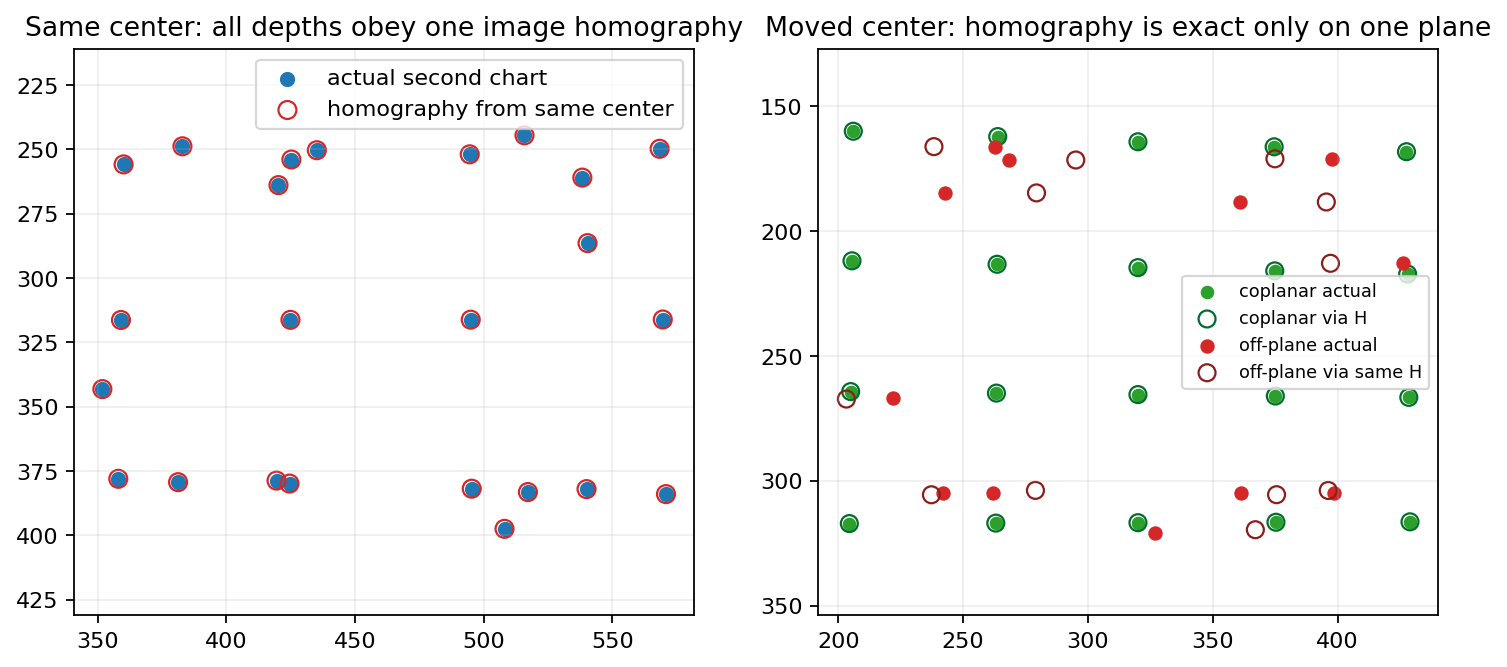

(1.797546735911271e-13, 1.2710574864626038e-13, 27.704673239050187)

In [4]:
def image_plane_frame(K, R, C, width=640, height=480, depth=1.15):
    corners = np.array([[0.0, 0.0, 1.0], [width, 0.0, 1.0], [width, height, 1.0], [0.0, height, 1.0], [0.0, 0.0, 1.0]])
    invK = np.linalg.inv(K)
    world = []
    for corner in corners:
        ray_cam = invK @ corner
        ray_cam = ray_cam / ray_cam[2] * depth
        world.append(C + R.T @ ray_cam)
    return np.array(world)


fig3d = go.Figure()
fig3d.add_trace(go.Scatter3d(x=points3d[:, 0], y=points3d[:, 1], z=points3d[:, 2], mode="markers", marker={"size": 4, "color": "#1f77b4"}, name="scene points"))
for idx, (R, C) in enumerate(zip(rotations, centers), start=1):
    frame = image_plane_frame(K, R, C)
    fig3d.add_trace(go.Scatter3d(x=[C[0]], y=[C[1]], z=[C[2]], mode="markers+text", text=[f"C{idx}"], textposition="top center", marker={"size": 6}, name=f"camera {idx}"))
    fig3d.add_trace(go.Scatter3d(x=frame[:, 0], y=frame[:, 1], z=frame[:, 2], mode="lines", line={"width": 4}, name=f"image plane {idx}"))

for point in points3d[:8]:
    C = centers[0]
    fig3d.add_trace(go.Scatter3d(x=[C[0], point[0]], y=[C[1], point[1]], z=[C[2], point[2]], mode="lines", line={"width": 2, "color": "rgba(50,50,50,0.35)"}, showlegend=False))

fig3d.update_layout(
    title="Pinhole cameras: image measurements are labels on rays through a center",
    scene={"xaxis_title": "X", "yaxis_title": "Y", "zaxis_title": "Z", "aspectmode": "data"},
    margin={"l": 0, "r": 0, "b": 0, "t": 40},
    legend={"orientation": "h", "y": -0.05},
)
scene_path = save_plotly_html(fig3d, TOPIC, "interactive", "pinhole-rays-camera-centers.html")
artifact_paths.append(scene_path)
display_artifact(scene_path, width=880, height=560)

C_same = centers[0]
R_same = rotation_y(np.deg2rad(9.0)) @ rotation_x(np.deg2rad(-5.0)) @ rotations[0]
P_same = camera_matrix(K, R_same, C_same)
x_same = project_points(P_same, points3d)
H_same_est = dlt_homography(x1, x_same)
same_center_error = float(np.max(np.linalg.norm(apply_homography(H_same_est, x1) - x_same, axis=1)))

plane_points = np.array([[x, y, 3.05] for x in np.linspace(-0.95, 0.95, 5) for y in np.linspace(-0.65, 0.65, 4)])
off_plane_points = points3d[np.abs(points3d[:, 2] - 3.05) > 0.05]
x1_plane = project_points(P1, plane_points)
x2_plane = project_points(P2, plane_points)
H_plane_views = dlt_homography(x1_plane, x2_plane)
plane_homography_error = float(np.max(np.linalg.norm(apply_homography(H_plane_views, x1_plane) - x2_plane, axis=1)))
off_plane_homography_error = float(np.median(np.linalg.norm(apply_homography(H_plane_views, project_points(P1, off_plane_points)) - project_points(P2, off_plane_points), axis=1)))

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.6))
axes[0].scatter(x_same[:, 0], x_same[:, 1], s=34, label="actual second chart", color="#1f77b4")
axes[0].scatter(apply_homography(H_same_est, x1)[:, 0], apply_homography(H_same_est, x1)[:, 1], s=65, facecolors="none", edgecolors="#d62728", label="homography from same center")
axes[0].set_title("Same center: all depths obey one image homography")
axes[0].invert_yaxis()
axes[0].set_aspect("equal", adjustable="datalim")
axes[0].legend()
axes[0].grid(alpha=0.2)

plane_pred = apply_homography(H_plane_views, x1_plane)
off_pred = apply_homography(H_plane_views, project_points(P1, off_plane_points))
off_actual = project_points(P2, off_plane_points)
axes[1].scatter(x2_plane[:, 0], x2_plane[:, 1], s=26, color="#2ca02c", label="coplanar actual")
axes[1].scatter(plane_pred[:, 0], plane_pred[:, 1], s=58, facecolors="none", edgecolors="#006d2c", label="coplanar via H")
axes[1].scatter(off_actual[:, 0], off_actual[:, 1], s=30, color="#d62728", label="off-plane actual")
axes[1].scatter(off_pred[:, 0], off_pred[:, 1], s=58, facecolors="none", edgecolors="#8c1d18", label="off-plane via same H")
axes[1].set_title("Moved center: homography is exact only on one plane")
axes[1].invert_yaxis()
axes[1].set_aspect("equal", adjustable="datalim")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.2)

homography_case_path = save_matplotlib(fig, TOPIC, "figures", "central-projection-homography-cases.png")
plt.close(fig)
artifact_paths.append(homography_case_path)
display_artifact(homography_case_path, width=880)

camera_ranks = [int(np.linalg.matrix_rank(P)) for P in cameras]
check_values.update({
    "camera_matrix_ranks": camera_ranks,
    "same_center_homography_max_error": same_center_error,
    "plane_homography_max_error": plane_homography_error,
    "off_plane_homography_median_error": off_plane_homography_error,
})
check_values["same_center_homography_max_error"], check_values["plane_homography_max_error"], check_values["off_plane_homography_median_error"]


## 3. A Synthetic Image Warp: Shape Is Not The Invariant

The chapter's first examples are ordinary visual experiences: squares stop looking square, circles stop looking circular, and parallel lines meet. The cell below uses a synthetic image, not a source figure, to make that claim inspectable. OpenCV applies a perspective warp to a clean grid so the learner can see what a projective transformation does to raster measurements.


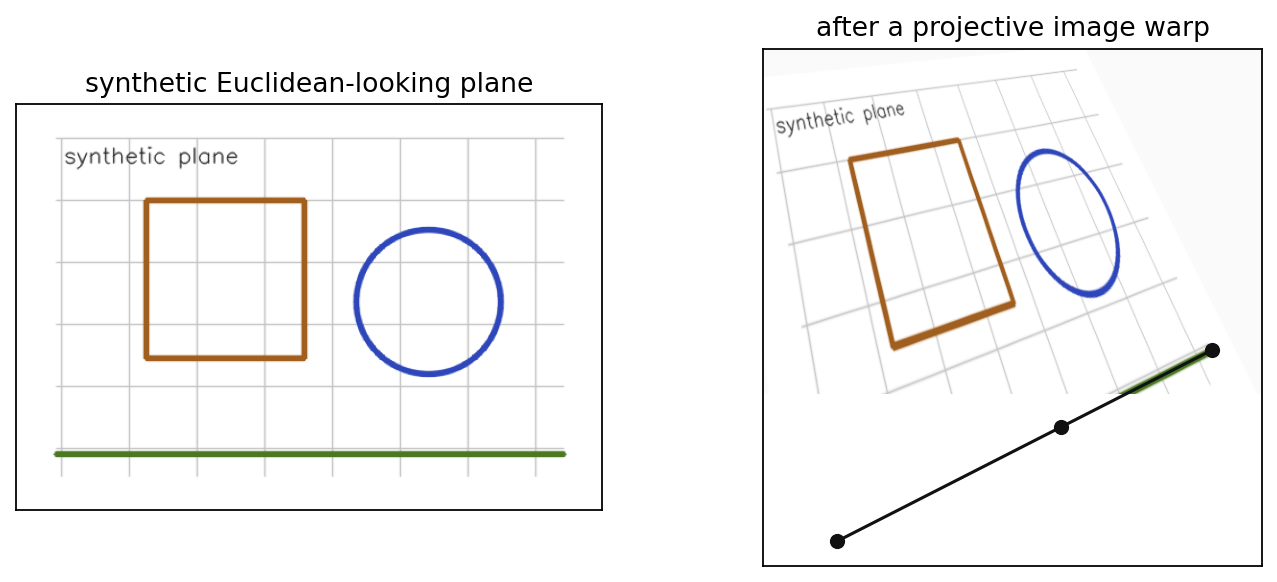

(5.684341886080802e-14, 0.0)

In [5]:
height, width = 360, 520
image = np.full((height, width, 3), 255, dtype=np.uint8)
for x in range(40, width, 60):
    cv2.line(image, (x, 30), (x, height - 30), (195, 195, 195), 1, cv2.LINE_AA)
for y in range(30, height, 55):
    cv2.line(image, (35, y), (width - 35, y), (195, 195, 195), 1, cv2.LINE_AA)
cv2.rectangle(image, (115, 85), (255, 225), (30, 95, 160), 3, cv2.LINE_AA)
cv2.circle(image, (365, 175), 64, (185, 70, 45), 3, cv2.LINE_AA)
cv2.line(image, (35, 310), (485, 310), (35, 120, 75), 3, cv2.LINE_AA)
cv2.putText(image, "synthetic plane", (42, 52), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (40, 40, 40), 1, cv2.LINE_AA)

H_img = np.array([[0.96, 0.18, -36.0], [-0.075, 1.06, 34.0], [0.00075, -0.00105, 1.0]])
warped = cv2.warpPerspective(image, H_img, (width, height), flags=cv2.INTER_LINEAR, borderValue=(250, 250, 250))

sample_line = np.array([[[35.0, 310.0]], [[260.0, 310.0]], [[485.0, 310.0]]], dtype=np.float64)
cv2_points = cv2.perspectiveTransform(sample_line, H_img).reshape(-1, 2)
np_points = apply_homography(H_img, sample_line.reshape(-1, 2))
line_after = line_through(homogenize(cv2_points[[0]])[0], homogenize(cv2_points[[-1]])[0])
midpoint_line_residual = normalized_incidence(line_after, homogenize(cv2_points[[1]])[0])
cv2_numpy_residual = float(np.max(np.linalg.norm(cv2_points - np_points, axis=1)))

fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.2))
for ax, im, title in [(axes[0], image, "synthetic Euclidean-looking plane"), (axes[1], warped, "after a projective image warp")]:
    ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
axes[1].scatter(cv2_points[:, 0], cv2_points[:, 1], s=34, color="#111111")
axes[1].plot(cv2_points[:, 0], cv2_points[:, 1], color="#111111", lw=1.4)
warp_path = save_matplotlib(fig, TOPIC, "figures", "projective-image-warp-lines-stay-lines.png")
plt.close(fig)
artifact_paths.append(warp_path)
display_artifact(warp_path, width=880)

check_values.update({
    "opencv_homogeneous_point_agreement": cv2_numpy_residual,
    "warped_line_midpoint_incidence": float(midpoint_line_residual),
})
check_values["opencv_homogeneous_point_agreement"], check_values["warped_line_midpoint_incidence"]


## 4. Two Views, Epipolar Lines, And Transfer

With two moved camera centers, a point in one image no longer determines a point in the other image. It determines an epipolar line. The fundamental matrix packages that incidence relation: each correspondence should satisfy `x2.T @ F @ x1 = 0`, and `F` must have rank 2.

Once two views triangulate a 3D point, transfer to a third view is just another projection. This mirrors the chapter's transfer recipe while keeping the algebra transparent.


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


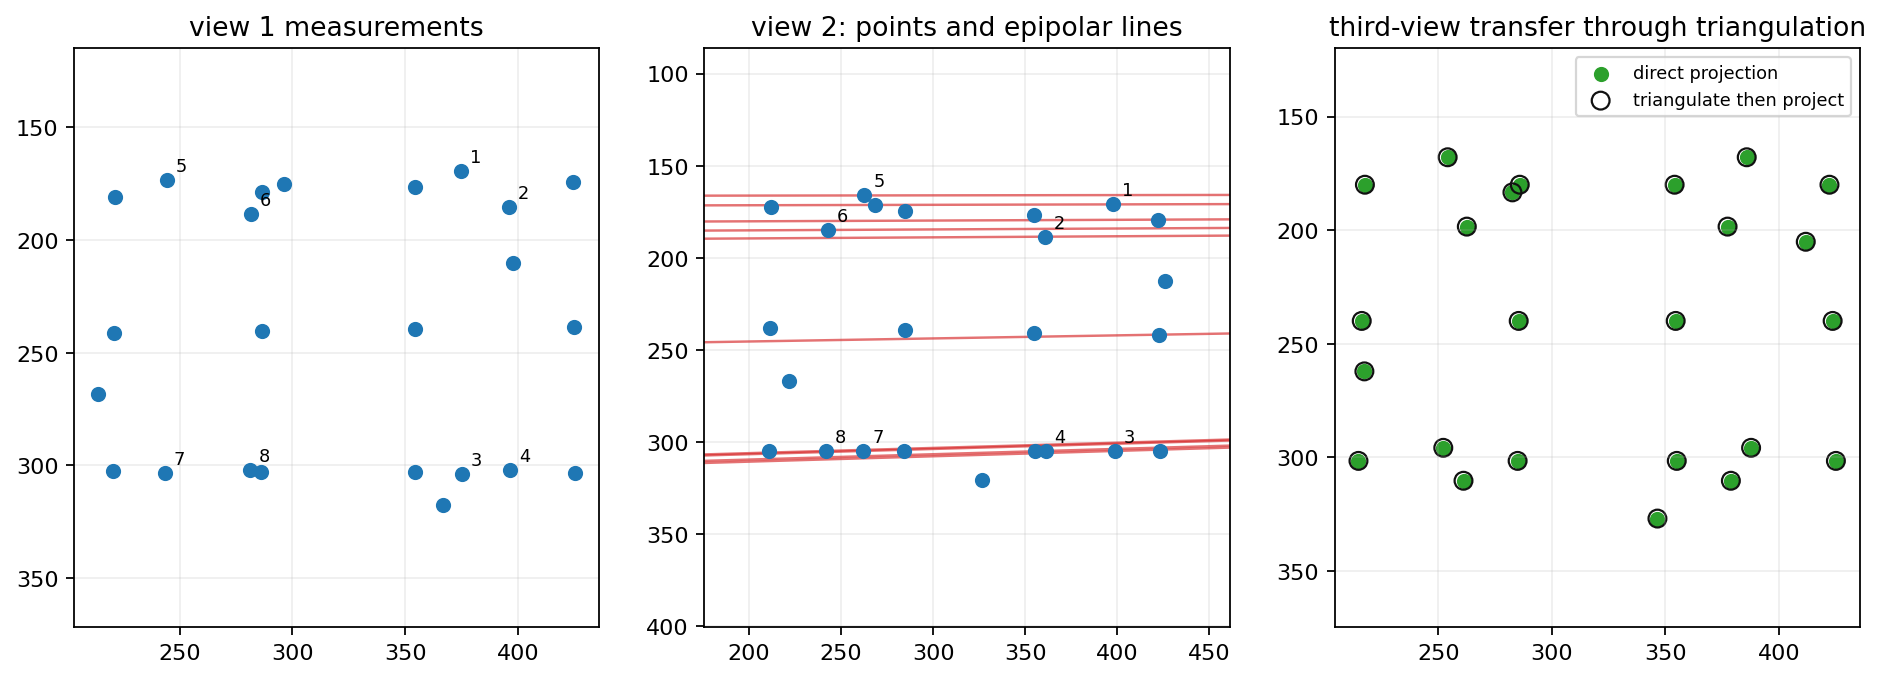

([0.9999999633225685, 0.00027084102684046655, 3.6993034689444894e-20],
 8.346987189945828e-14)

In [6]:
F12 = fundamental_from_cameras(P1, P2)
F_singular_values = np.linalg.svd(F12, compute_uv=False)
epi_errors = sampson_errors(F12, x1, x2)
triangulated = linear_triangulate(P1, P2, x1, x2)
triangulation_rmse = float(np.sqrt(np.mean(np.sum((triangulated - points3d) ** 2, axis=1))))
x3_transfer = project_points(P3, triangulated)
third_view_transfer_rmse = float(np.sqrt(np.mean(np.sum((x3_transfer - x3) ** 2, axis=1))))


def draw_image_points(ax, pts, title):
    ax.scatter(pts[:, 0], pts[:, 1], s=34, color="#1f77b4", zorder=3)
    for idx, p in enumerate(pts[:8], start=1):
        ax.annotate(str(idx), p, xytext=(4, 4), textcoords="offset points", fontsize=8)
    ax.set_title(title)
    ax.invert_yaxis()
    ax.set_aspect("equal", adjustable="datalim")
    ax.grid(alpha=0.2)


fig, axes = plt.subplots(1, 3, figsize=(14.4, 4.7))
draw_image_points(axes[0], x1, "view 1 measurements")
draw_image_points(axes[1], x2, "view 2: points and epipolar lines")
xlim2, ylim2 = normalize_image_points(x2)
for idx, line in enumerate((F12 @ homogenize(x1).T).T[:10]):
    segment = line_segment_in_box(line, xlim2, ylim2)
    if segment is not None:
        axes[1].plot(segment[:, 0], segment[:, 1], lw=1.1, alpha=0.65, color="#d62728")
axes[1].set_xlim(*xlim2)
axes[1].set_ylim(ylim2[1], ylim2[0])

axes[2].scatter(x3[:, 0], x3[:, 1], s=34, color="#2ca02c", label="direct projection")
axes[2].scatter(x3_transfer[:, 0], x3_transfer[:, 1], s=64, facecolors="none", edgecolors="#111111", label="triangulate then project")
for actual, transferred in zip(x3[:8], x3_transfer[:8]):
    axes[2].plot([actual[0], transferred[0]], [actual[1], transferred[1]], color="#555555", lw=0.8)
axes[2].set_title("third-view transfer through triangulation")
axes[2].invert_yaxis()
axes[2].set_aspect("equal", adjustable="datalim")
axes[2].grid(alpha=0.2)
axes[2].legend(fontsize=8)

epipolar_path = save_matplotlib(fig, TOPIC, "figures", "two-view-epipolar-transfer.png")
plt.close(fig)
artifact_paths.append(epipolar_path)
display_artifact(epipolar_path, width=940)

check_values.update({
    "fundamental_singular_values": [float(v) for v in F_singular_values],
    "fundamental_smallest_singular_value": float(F_singular_values[-1]),
    "max_epipolar_sampson_error": float(np.max(epi_errors)),
    "triangulation_rmse": triangulation_rmse,
    "third_view_transfer_rmse": third_view_transfer_rmse,
})
check_values["fundamental_singular_values"], check_values["third_view_transfer_rmse"]


## 5. Projective Ambiguity And The Euclidean Upgrade

The two-view reconstruction is only projective unless additional information fixes metric structure. The algebraic reason is short: `P X` is unchanged if points become `H X` and cameras become `P H^{-1}`. The visual consequence is more important: a reconstructed point cloud can explain the images perfectly while its Euclidean shape is distorted.

Calibration supplies a metric object. For a camera with intrinsic matrix `K`, the image of the absolute conic is represented by `omega = K^{-T} K^{-1}`. It lets the image compute angles between back-projected rays, which is the kind of Euclidean information a purely projective reconstruction lacks.


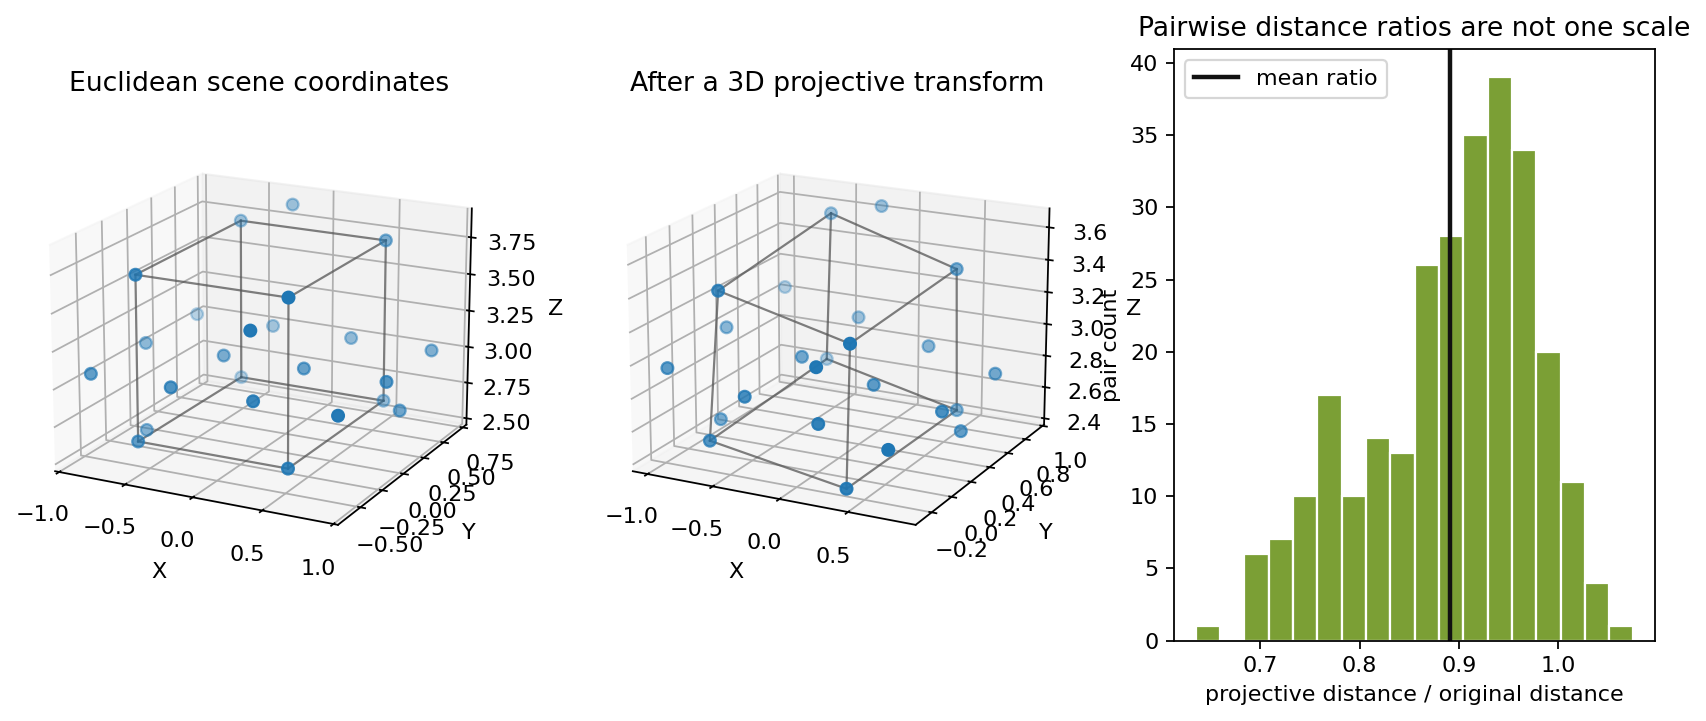

(1.7288250917028504e-13, 0.09381872343551695, 1.1102230246251565e-16)

In [7]:
H4 = np.array([
    [1.08, 0.12, -0.04, 0.08],
    [-0.05, 0.96, 0.10, -0.03],
    [0.06, -0.03, 1.02, 0.16],
    [0.075, -0.055, 0.045, 1.0],
])
assert abs(np.linalg.det(H4)) > 1e-6
H4_inv = np.linalg.inv(H4)
Xh = homogenize(points3d)
points_projective = dehomogenize((H4 @ Xh.T).T)
projective_cameras = [P @ H4_inv for P in cameras]
projective_projection_errors = []
for P, Pp, x in zip(cameras, projective_cameras, [x1, x2, x3]):
    projective_projection_errors.append(np.max(np.linalg.norm(project_points(Pp, points_projective) - x, axis=1)))
projective_reprojection_max = float(max(projective_projection_errors))

original_distances = pairwise_distances(points3d)
projective_distances = pairwise_distances(points_projective)
distance_ratios = projective_distances / np.maximum(original_distances, 1e-12)
distance_ratio_cv = float(np.std(distance_ratios) / np.mean(distance_ratios))

omega = np.linalg.inv(K).T @ np.linalg.inv(K)
xa = homogenize(x1[[0]])[0]
xb = homogenize(x1[[7]])[0]
ray_a = np.linalg.inv(K) @ xa
ray_b = np.linalg.inv(K) @ xb
cos_from_rays = float(ray_a @ ray_b / (np.linalg.norm(ray_a) * np.linalg.norm(ray_b)))
cos_from_iac = float((xa @ omega @ xb) / np.sqrt((xa @ omega @ xa) * (xb @ omega @ xb)))
iac_angle_residual = abs(cos_from_rays - cos_from_iac)

fig = plt.figure(figsize=(13.2, 4.8))
ax1 = fig.add_subplot(1, 3, 1, projection="3d")
ax2 = fig.add_subplot(1, 3, 2, projection="3d")
ax3 = fig.add_subplot(1, 3, 3)
for ax, pts, title in [(ax1, points3d, "Euclidean scene coordinates"), (ax2, points_projective, "After a 3D projective transform")]:
    ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=28, color="#1f77b4")
    for edge in [(0, 1), (0, 2), (0, 4), (7, 6), (7, 5), (7, 3), (1, 3), (1, 5), (2, 3), (2, 6), (4, 5), (4, 6)]:
        ax.plot(pts[list(edge), 0], pts[list(edge), 1], pts[list(edge), 2], color="#555555", lw=1.0, alpha=0.75)
    ax.set_title(title)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.view_init(elev=18, azim=-63)

ax3.hist(distance_ratios, bins=18, color="#7b9f35", edgecolor="white")
ax3.axvline(np.mean(distance_ratios), color="#111111", lw=2, label="mean ratio")
ax3.set_title("Pairwise distance ratios are not one scale")
ax3.set_xlabel("projective distance / original distance")
ax3.set_ylabel("pair count")
ax3.legend()

ambiguity_path = save_matplotlib(fig, TOPIC, "figures", "projective-ambiguity-euclidean-upgrade.png")
plt.close(fig)
artifact_paths.append(ambiguity_path)
display_artifact(ambiguity_path, width=940)

check_values.update({
    "projective_ambiguity_reprojection_max": projective_reprojection_max,
    "projective_distance_ratio_cv": distance_ratio_cv,
    "iac_angle_cosine_residual": float(iac_angle_residual),
})
check_values["projective_ambiguity_reprojection_max"], check_values["projective_distance_ratio_cv"], check_values["iac_angle_cosine_residual"]


## 6. Route Through The Chapter

The introduction is a dependency tour. Projective representation comes first; camera projection turns it into image formation; correspondences give two-view and three-view constraints; reconstruction remains projective until calibration or scene assumptions identify the affine and Euclidean structure. Dense models and video augmentation are rewards for getting that chain right.


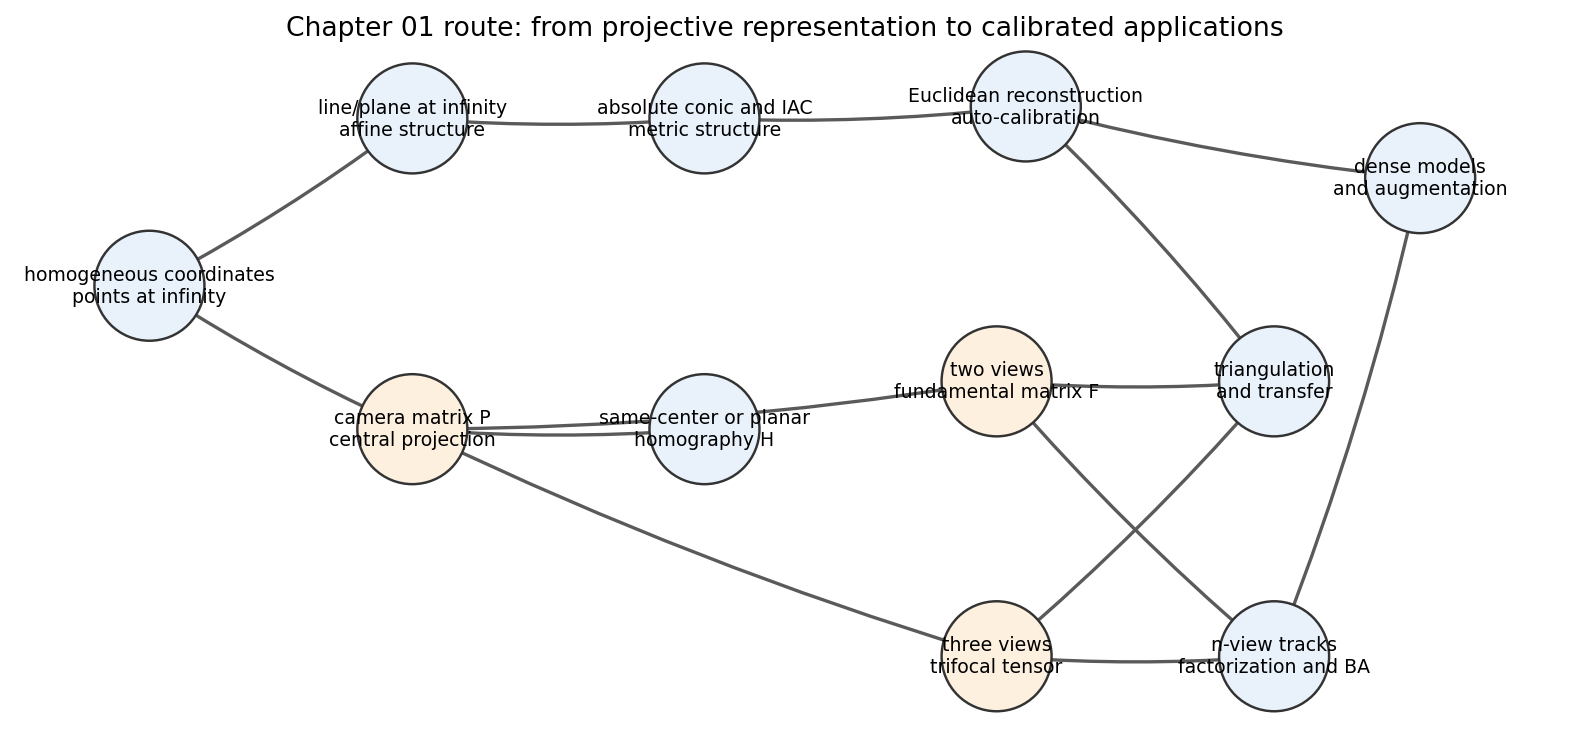

(True, True)

In [8]:
G = nx.DiGraph()
nodes = {
    "homogeneous coordinates/npoints at infinity": (0.0, 2.0),
    "line/plane at infinity/naffine structure": (1.8, 2.7),
    "absolute conic and IAC/nmetric structure": (3.8, 2.7),
    "camera matrix P/ncentral projection": (1.8, 1.4),
    "same-center or planar/nhomography H": (3.8, 1.4),
    "two views/nfundamental matrix F": (5.8, 1.6),
    "triangulation/nand transfer": (7.7, 1.6),
    "three views/ntrifocal tensor": (5.8, 0.45),
    "n-view tracks/nfactorization and BA": (7.7, 0.45),
    "Euclidean reconstruction/nauto-calibration": (6.0, 2.75),
    "dense models/nand augmentation": (8.7, 2.45),
}
G.add_nodes_from(nodes)
G.add_edges_from([
    ("homogeneous coordinates/npoints at infinity", "line/plane at infinity/naffine structure"),
    ("line/plane at infinity/naffine structure", "absolute conic and IAC/nmetric structure"),
    ("homogeneous coordinates/npoints at infinity", "camera matrix P/ncentral projection"),
    ("camera matrix P/ncentral projection", "same-center or planar/nhomography H"),
    ("camera matrix P/ncentral projection", "two views/nfundamental matrix F"),
    ("two views/nfundamental matrix F", "triangulation/nand transfer"),
    ("camera matrix P/ncentral projection", "three views/ntrifocal tensor"),
    ("three views/ntrifocal tensor", "triangulation/nand transfer"),
    ("two views/nfundamental matrix F", "n-view tracks/nfactorization and BA"),
    ("three views/ntrifocal tensor", "n-view tracks/nfactorization and BA"),
    ("absolute conic and IAC/nmetric structure", "Euclidean reconstruction/nauto-calibration"),
    ("triangulation/nand transfer", "Euclidean reconstruction/nauto-calibration"),
    ("n-view tracks/nfactorization and BA", "dense models/nand augmentation"),
    ("Euclidean reconstruction/nauto-calibration", "dense models/nand augmentation"),
])

fig, ax = plt.subplots(figsize=(12.4, 5.4))
pos = nodes
node_colors = ["#e9f2fb" if "camera" not in n and "views" not in n else "#fdf0df" for n in G.nodes]
nx.draw_networkx_nodes(G, pos, node_size=2450, node_color=node_colors, edgecolors="#333333", linewidths=1.1, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8.5, ax=ax)
nx.draw_networkx_edges(G, pos, arrows=True, arrowstyle="-|>", arrowsize=15, width=1.5, edge_color="#5a5a5a", connectionstyle="arc3,rad=0.04", ax=ax)
ax.set_title("Chapter 01 route: from projective representation to calibrated applications")
ax.set_axis_off()
route_path = save_matplotlib(fig, TOPIC, "figures", "chapter-tour-route-graph.png")
plt.close(fig)
artifact_paths.append(route_path)
display_artifact(route_path, width=900)

check_values.update({
    "route_graph_is_dag": bool(nx.is_directed_acyclic_graph(G)),
    "route_graph_node_count": int(G.number_of_nodes()),
    "route_graph_edge_count": int(G.number_of_edges()),
    "projection_reaches_applications": bool(nx.has_path(G, "camera matrix P/ncentral projection", "dense models/nand augmentation")),
})
check_values["route_graph_is_dag"], check_values["projection_reaches_applications"]


## Applied Lab: Noise, Linear Initialization, And Reconstruction Quality

The chapter repeatedly separates initialization from refinement: linear projective methods produce usable starting points, and bundle adjustment or calibration constraints refine them. This small lab injects pixel noise into two-view correspondences, estimates a rank-2 fundamental matrix with the normalized eight-point algorithm, and triangulates with the known cameras so the effect of measurement noise is visible.

The lab is deliberately modest. It is not a replacement for bundle adjustment; it is a sanity check for the chapter's workflow: measured correspondences produce a projective relation, residuals diagnose that relation, and downstream 3D estimates become less reliable as measurement noise grows.


[two-view-noise-sensitivity.csv](Multiple-View-Geometry-in-Computer-Vision/artifacts/chapter-01/tables/two-view-noise-sensitivity.csv)

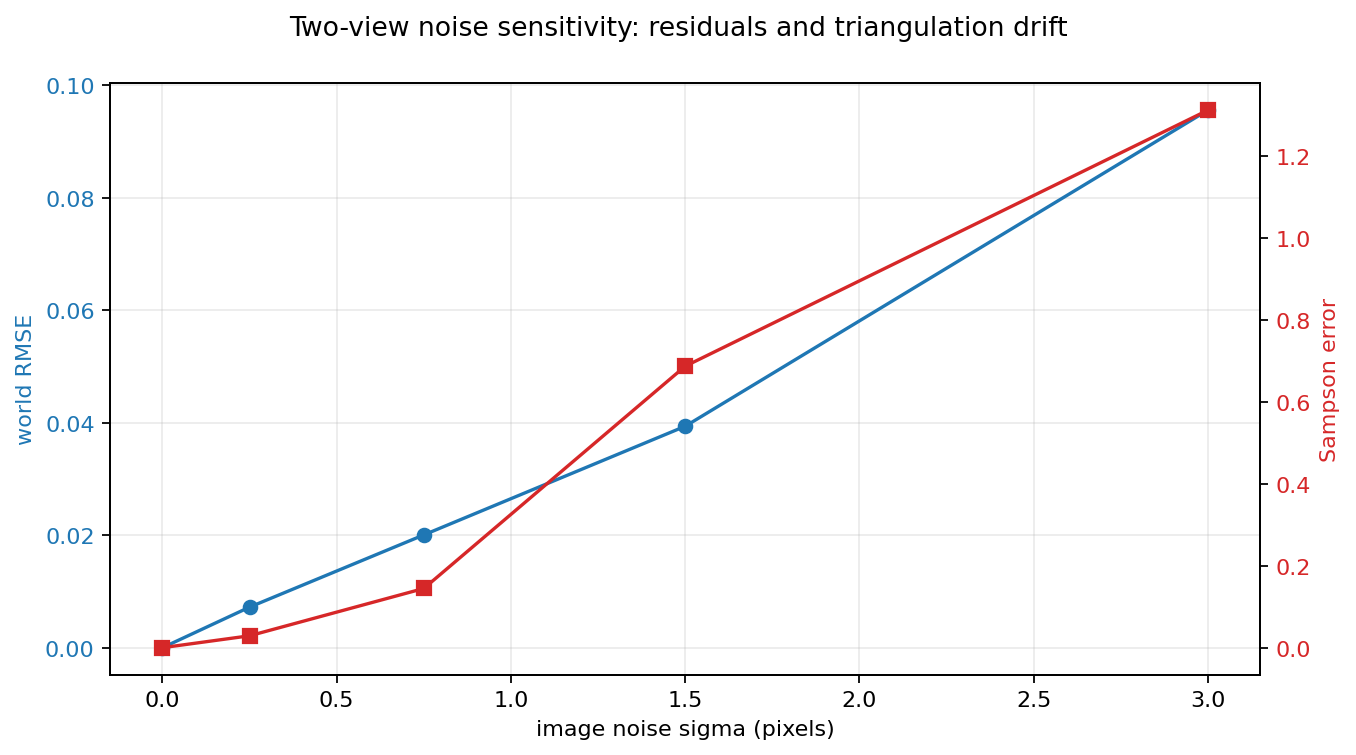

[{'pixel_noise_sigma': 0.0,
  'median_sampson_estimated_F': 1.0433792189653376e-22,
  'median_sampson_true_F': 1.1595466729535362e-22,
  'triangulation_rmse_world_units': 2.2874423430909664e-15,
  'estimated_F_smallest_singular_value': 8.796671459596832e-20},
 {'pixel_noise_sigma': 0.25,
  'median_sampson_estimated_F': 0.035870997147660545,
  'median_sampson_true_F': 0.029023413333826197,
  'triangulation_rmse_world_units': 0.007213235807336809,
  'estimated_F_smallest_singular_value': 2.1858470256128297e-19},
 {'pixel_noise_sigma': 0.75,
  'median_sampson_estimated_F': 0.0829000712215376,
  'median_sampson_true_F': 0.14449131611914007,
  'triangulation_rmse_world_units': 0.020056444632479214,
  'estimated_F_smallest_singular_value': 5.775866842660257e-19},
 {'pixel_noise_sigma': 1.5,
  'median_sampson_estimated_F': 0.5698677215217157,
  'median_sampson_true_F': 0.6867529716250875,
  'triangulation_rmse_world_units': 0.03937440340432895,
  'estimated_F_smallest_singular_value': 1.51082

In [9]:
noise_rows = []
noise_levels = [0.0, 0.25, 0.75, 1.5, 3.0]
for sigma in noise_levels:
    noisy_x1 = x1 + rng.normal(0.0, sigma, size=x1.shape)
    noisy_x2 = x2 + rng.normal(0.0, sigma, size=x2.shape)
    F_est = eight_point(noisy_x1, noisy_x2)
    svals = np.linalg.svd(F_est, compute_uv=False)
    noisy_epi = sampson_errors(F_est, noisy_x1, noisy_x2)
    noisy_true_model_epi = sampson_errors(F12, noisy_x1, noisy_x2)
    noisy_triangulated = linear_triangulate(P1, P2, noisy_x1, noisy_x2)
    noisy_rmse = float(np.sqrt(np.mean(np.sum((noisy_triangulated - points3d) ** 2, axis=1))))
    noise_rows.append({
        "pixel_noise_sigma": sigma,
        "median_sampson_estimated_F": float(np.median(noisy_epi)),
        "median_sampson_true_F": float(np.median(noisy_true_model_epi)),
        "triangulation_rmse_world_units": noisy_rmse,
        "estimated_F_smallest_singular_value": float(svals[-1]),
    })

noise_table_path = save_csv(noise_rows, TOPIC, "tables", "two-view-noise-sensitivity.csv")
artifact_paths.append(noise_table_path)
display_artifact(noise_table_path)

fig, ax1 = plt.subplots(figsize=(8.6, 4.8))
sigmas = np.array([row["pixel_noise_sigma"] for row in noise_rows])
tri_rmse = np.array([row["triangulation_rmse_world_units"] for row in noise_rows])
true_sampson = np.array([row["median_sampson_true_F"] for row in noise_rows])
ax1.plot(sigmas, tri_rmse, marker="o", color="#1f77b4", label="triangulation RMSE")
ax1.set_xlabel("image noise sigma (pixels)")
ax1.set_ylabel("world RMSE", color="#1f77b4")
ax1.tick_params(axis="y", labelcolor="#1f77b4")
ax1.grid(alpha=0.25)
ax2 = ax1.twinx()
ax2.plot(sigmas, true_sampson, marker="s", color="#d62728", label="median Sampson error under true F")
ax2.set_ylabel("Sampson error", color="#d62728")
ax2.tick_params(axis="y", labelcolor="#d62728")
fig.suptitle("Two-view noise sensitivity: residuals and triangulation drift")
fig.tight_layout()
noise_path = save_matplotlib(fig, TOPIC, "figures", "epipolar-noise-sensitivity.png")
plt.close(fig)
artifact_paths.append(noise_path)
display_artifact(noise_path, width=820)

check_values.update({
    "noise_lab_row_count": len(noise_rows),
    "noise_lab_zero_noise_rmse": float(noise_rows[0]["triangulation_rmse_world_units"]),
    "noise_lab_high_noise_rmse": float(noise_rows[-1]["triangulation_rmse_world_units"]),
    "noise_lab_max_estimated_F_smallest_singular_value": float(max(row["estimated_F_smallest_singular_value"] for row in noise_rows)),
})
noise_rows


## Final Sanity Checks

The final cell asserts the notebook contract: every artifact exists and is nonempty, the old generic artifact names are absent from this chapter subtree, projective incidences are numerically small, camera and fundamental matrices have the required ranks, transfer and triangulation are consistent on exact synthetic data, projective ambiguity preserves images while distorting Euclidean distances, and the IAC angle identity agrees with direct ray geometry.


In [10]:
summary_path = save_json(check_values, TOPIC, "checks", "chapter-01-tour-invariants.json")
artifact_paths.append(summary_path)
display_artifact(summary_path)

flagged_generic_names = {
    "-".join(parts) + suffix
    for parts, suffix in [
        (("concept", "map"), ".png"),
        (("geometry", "scene"), ".png"),
        (("diagnostic", "dashboard"), ".png"),
        (("constraint", "dashboard"), ".png"),
        (("numeric", "summary"), ".json"),
    ]
}
flagged_existing = [path.name for path in ARTIFACT_ROOT.rglob("*") if path.is_file() and path.name in flagged_generic_names]

assert_artifacts(artifact_paths, min_bytes=256)
assert not flagged_existing, flagged_existing
assert check_values["vanishing_family_max_incidence"] < 1e-9
assert check_values["vanishing_points_on_horizon_residual"] < 1e-9
assert check_values["camera_matrix_ranks"] == [3, 3, 3]
assert check_values["same_center_homography_max_error"] < 1e-6
assert check_values["plane_homography_max_error"] < 1e-6
assert check_values["off_plane_homography_median_error"] > 1.0
assert check_values["opencv_homogeneous_point_agreement"] < 1e-3
assert check_values["warped_line_midpoint_incidence"] < 1e-6
assert check_values["fundamental_smallest_singular_value"] < 1e-10
assert check_values["max_epipolar_sampson_error"] < 1e-8
assert check_values["triangulation_rmse"] < 1e-8
assert check_values["third_view_transfer_rmse"] < 1e-8
assert check_values["projective_ambiguity_reprojection_max"] < 1e-8
assert check_values["projective_distance_ratio_cv"] > 0.03
assert check_values["iac_angle_cosine_residual"] < 1e-12
assert check_values["route_graph_is_dag"]
assert check_values["projection_reaches_applications"]
assert check_values["noise_lab_row_count"] == len(noise_levels)
assert check_values["noise_lab_high_noise_rmse"] > check_values["noise_lab_zero_noise_rmse"]

final_sanity = {
    "artifact_count": len(artifact_paths),
    "artifacts": [str(path.relative_to(BOOK_ROOT)) for path in artifact_paths],
    "checks": check_values,
}
final_sanity


`artifacts/chapter-01/checks/chapter-01-tour-invariants.json`

{'artifact_count': 10,
 'artifacts': ['artifacts//chapter-01//figures//vanishing-line-projective-strata.png',
  'artifacts//chapter-01//interactive//pinhole-rays-camera-centers.html',
  'artifacts//chapter-01//figures//central-projection-homography-cases.png',
  'artifacts//chapter-01//figures//projective-image-warp-lines-stay-lines.png',
  'artifacts//chapter-01//figures//two-view-epipolar-transfer.png',
  'artifacts//chapter-01//figures//projective-ambiguity-euclidean-upgrade.png',
  'artifacts//chapter-01//figures//chapter-tour-route-graph.png',
  'artifacts//chapter-01//tables//two-view-noise-sensitivity.csv',
  'artifacts//chapter-01//figures//epipolar-noise-sensitivity.png',
  'artifacts//chapter-01//checks//chapter-01-tour-invariants.json'],
 'checks': {'vanishing_family_max_incidence': 4.0205214473426037e-16,
  'vanishing_points_on_horizon_residual': 0.0,
  'camera_matrix_ranks': [3, 3, 3],
  'same_center_homography_max_error': 1.797546735911271e-13,
  'plane_homography_max_err

## Takeaways

- Projective geometry is the correct language for both 3D scene points and 2D image measurements because homogeneous coordinates include finite and ideal points in one representation.
- A pinhole camera labels rays through a center; depth is lost, but incidence relations remain available.
- Homographies are exact for same-center images and for coplanar scenes; moved-center non-planar scenes require epipolar or higher-view constraints.
- The fundamental matrix is a rank-2 incidence object, not just a fitted array. Its residuals and singular values are part of the geometry.
- Uncalibrated reconstruction is projective: it can preserve every image measurement while distorting Euclidean shape.
- Calibration, the IAC, the plane at infinity, and the absolute conic are the bridge from projective reconstruction to Euclidean models, dense reconstruction, and video augmentation.
